# Projektübersicht: Bildung, BIP und Arbeitslosigkeit in der EU

## Zweck der Analyse

In diesem Projekt wird untersucht, ob ein Zusammenhang zwischen der Bildungsquote, dem BIP pro Kopf und der Arbeitslosenquote in den EU-Ländern besteht. 

---

## Forschungshypothesen

**Hypothese 1:** EU-Länder mit höherem Anteil an Hochschulabsolventen (Bildungsquote) weisen ein höheres BIP pro Kopf auf.

**Hypothese 2:** EU-Länder mit höherer Bildungsquote haben eine niedrigere Arbeitslosenquote.

**Hypothese 3:** EU-Länder mit höherem BIP pro Kopf haben eine niedrigere Arbeitslosenquote.


Alle Daten stammen von **Eurostat** 

In [91]:
# Importiere notwendige Bibliotheken für Datenanalyse und Visualisierung
import pandas as pd  # Datenmanipulation und -analyse
import numpy as np  # Numerisches Rechnen
from scipy.stats import pearsonr  # Berechnung des Pearson-Korrelationskoeffizienten
import matplotlib.pyplot as plt  # Erstellung von Plots und Visualisierungen
import seaborn as sns  # Statistische Datenvisualisierung
from sklearn.linear_model import LinearRegression



In [92]:
# Datenimport aus Eurostat CSV-Dateien im Ordner
df_ed = pd.read_csv('estat_edat_lfse_03_filtered_en.csv', usecols=['geo','TIME_PERIOD','OBS_VALUE'])  # Bildungsquote (tertiäre Ausbildung 25-34 Jahre)
df_gdp = pd.read_csv('estat_nama_10_pc_filtered_en.csv', usecols=['geo','TIME_PERIOD','OBS_VALUE'])  # BIP pro Kopf in PPS
df_unemp = pd.read_csv('estat_une_rt_a_filtered_en.csv', usecols=['geo','TIME_PERIOD','OBS_VALUE'])  # Arbeitslosenquote (15-74 Jahre)


In [93]:
df_ed.head(10)

,geo,TIME_PERIOD,OBS_VALUE
0,Austria,2013,24.9
1,Austria,2014,38.4
2,Austria,2015,38.6
3,Austria,2016,39.7
4,Austria,2017,40.3
5,Austria,2018,40.5
6,Austria,2019,41.6
7,Austria,2020,41.4
8,Austria,2021,42.4
9,Austria,2022,43.1


In [94]:
# Spalten umbenennen für klarere Handhabung
df_ed.rename(columns={'geo': 'country', 'TIME_PERIOD': 'year', 'OBS_VALUE': 'education_rate'}, inplace=True)
df_gdp.rename(columns={'geo': 'country', 'TIME_PERIOD': 'year', 'OBS_VALUE': 'gdp_per_capita'}, inplace=True)
df_unemp.rename(columns={'geo': 'country', 'TIME_PERIOD': 'year', 'OBS_VALUE': 'unemployment_rate'}, inplace=True)

In [95]:
df_ed['country'].unique() #Alle Länder anzeigen

array(['Austria', 'Bosnia and Herzegovina', 'Belgium', 'Bulgaria',
       'Switzerland', 'Cyprus', 'Czechia', 'Germany', 'Denmark',
       'Estonia', 'Greece', 'Spain',
       'European Union - 27 countries (from 2020)', 'Finland', 'France',
       'Croatia', 'Hungary', 'Ireland', 'Iceland', 'Italy', 'Lithuania',
       'Luxembourg', 'Latvia', 'Montenegro', 'North Macedonia', 'Malta',
       'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Serbia',
       'Sweden', 'Slovenia', 'Slovakia', 'Türkiye', 'United Kingdom'],
      dtype=object)

In [96]:
#Liste mit nur EU Länder erstellen
eu_countries = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia", "Finland", 
    "France", "Germany", "Greece", "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", 
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia", "Spain", "Sweden"
]

In [97]:
#Filtern nach nur EU Ländern die Dataframes
df_ed = df_ed[df_ed['country'].isin(eu_countries)]
df_gdp = df_gdp[df_gdp['country'].isin(eu_countries)]
df_unemp = df_unemp[df_unemp['country'].isin(eu_countries)]
print(df_ed['country'].describe()) #Check ob alle drin sind 27 brauchen wir


count         324
unique         27
top       Austria
freq           12
Name: country, dtype: object


In [98]:
# Daten zusammenführen (Merge nach Land und Jahr)
df = pd.merge(df_ed, df_gdp, on=['country','year'], how='inner')
df = pd.merge(df, df_unemp, on=['country','year'], how='inner')
print(df.head(10)) #check wie es aussieht


   country  year  education_rate  gdp_per_capita  unemployment_rate
0  Austria  2015            38.6         35681.6                6.1
1  Austria  2016            39.7         36385.4                6.5
2  Austria  2017            40.3         37011.9                5.9
3  Austria  2018            40.5         38414.6                5.2
4  Austria  2019            41.6         39259.3                4.8
5  Austria  2020            41.4         37382.4                6.0
6  Austria  2021            42.4         40182.4                6.2
7  Austria  2022            43.1         44418.8                4.8
8  Austria  2023            43.5         46171.3                5.1
9  Austria  2024            44.1         46883.1                5.2


In [99]:
df.describe()  # Check daten

,year,education_rate,gdp_per_capita,unemployment_rate
count,270.000000,270.000000,270.000000,270.000000
mean,2019.500000,42.815926,33419.221111,7.087037
std,2.877615,9.293456,14723.817925,3.665951
min,2015.000000,22.500000,13586.800000,2.000000
25%,2017.000000,35.325000,23937.850000,4.925000
50%,2019.500000,42.900000,30361.900000,6.300000
75%,2022.000000,48.500000,37447.950000,8.000000
max,2024.000000,65.200000,96249.000000,25.000000


# 270 Datenpunkte (27 Länder × 10 Jahre) das ist korrekt.

In [100]:
df.info() #Check Daten typen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            270 non-null    object 
 1   year               270 non-null    int64  
 2   education_rate     270 non-null    float64
 3   gdp_per_capita     270 non-null    float64
 4   unemployment_rate  270 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 10.7+ KB


In [101]:
df.isnull().sum()  # Überprüft auf fehlende Werte, sieht gut aus

country              0
year                 0
education_rate       0
gdp_per_capita       0
unemployment_rate    0
dtype: int64

In [102]:
df.isna().sum()

country              0
year                 0
education_rate       0
gdp_per_capita       0
unemployment_rate    0
dtype: int64

In [103]:
df.head(10)

,country,year,education_rate,gdp_per_capita,unemployment_rate
0,Austria,2015,38.6,35681.6,6.1
1,Austria,2016,39.7,36385.4,6.5
2,Austria,2017,40.3,37011.9,5.9
3,Austria,2018,40.5,38414.6,5.2
4,Austria,2019,41.6,39259.3,4.8
5,Austria,2020,41.4,37382.4,6.0
6,Austria,2021,42.4,40182.4,6.2
7,Austria,2022,43.1,44418.8,4.8
8,Austria,2023,43.5,46171.3,5.1
9,Austria,2024,44.1,46883.1,5.2


## Dataset Overview

After merging the three data sources, the combined dataset df has the following structure:

### Columns:
- **country**: Country name (EU-27 countries)
- **year**: Year (2015–2024)
- **education_rate**: Education rate share of 25–34-year-olds with a tertiary degree (%)
- **gdp_per_capita**: GDP per capita
- **unemployment_rate**: Unemployment rate (%, age group 15–74 years)

### Data availability:
- **Period**: 2015–2024 (limited by the availability of unemployment data from 2015 onward)
- **Countries**: 27 EU countries


After the merge, the data only contains country-year combinations for which all three indicators are available.

### Nun sind die Datensätze zusammengeführt und bereinigt worden und können für die explorative Analyse verwendet werden.

In [104]:
# Für jedes Jahr: sortiere nach Arbeitslosenquote absteigend
ranking = df.sort_values(['year', 'unemployment_rate'], ascending=[True, False])

#zeige pro Jahr nur das Land mit der höchsten Quote
top_per_year = ranking.groupby('year').first().reset_index()

print(top_per_year[['year', 'country', 'unemployment_rate']])

   year country  unemployment_rate
0  2015  Greece               25.0
1  2016  Greece               23.9
2  2017  Greece               21.8
3  2018  Greece               19.7
4  2019  Greece               17.9
5  2020  Greece               17.6
6  2021   Spain               14.9
7  2022   Spain               13.0
8  2023   Spain               12.2
9  2024   Spain               11.4


### Griechenland hatte von 2015 bis 2020 die höchste Arbeitslosenquote in der EU,
### von 2021-2024 hatte Spanien die höchste Arbeitslosenquote in der EU.

In [105]:
# Für jedes Jahr: sortiere nach Arbeitslosenquote absteigend
ranking = df.sort_values(['year', 'education_rate'], ascending=[True, False])

#zeige pro Jahr nur das Land mit der höchsten Quote
top_per_year = ranking.groupby('year').first().reset_index()

print(top_per_year[['year', 'country', 'education_rate']])

   year     country  education_rate
0  2015   Lithuania            54.8
1  2016      Cyprus            56.2
2  2017      Cyprus            57.0
3  2018      Cyprus            58.5
4  2019      Cyprus            59.1
5  2020  Luxembourg            60.6
6  2021  Luxembourg            62.6
7  2022     Ireland            63.0
8  2023     Ireland            62.7
9  2024     Ireland            65.2


### Die höchste Bildungsquote (Anteil der 25–34-Jährigen mit tertiärem Abschluss (%)) in der EU hat wechselt über die Jahre aber der maximale Anteil steigt über die Jahre


In [106]:
# Für jedes Jahr: sortiere nach Arbeitslosenquote absteigend
ranking = df.sort_values(['year', 'gdp_per_capita'], ascending=[True, False])

#zeige pro Jahr nur das Land mit der höchsten Quote
top_per_year = ranking.groupby('year').first().reset_index()

print(top_per_year[['year', 'country', 'gdp_per_capita']])

   year     country  gdp_per_capita
0  2015  Luxembourg         77581.8
1  2016  Luxembourg         78464.8
2  2017  Luxembourg         78895.5
3  2018  Luxembourg         78975.8
4  2019  Luxembourg         78735.2
5  2020  Luxembourg         77882.3
6  2021  Luxembourg         87091.5
7  2022  Luxembourg         89574.0
8  2023  Luxembourg         93488.9
9  2024  Luxembourg         96249.0


### Luxemburg hat das höchste BIP pro Kopf in der EU.

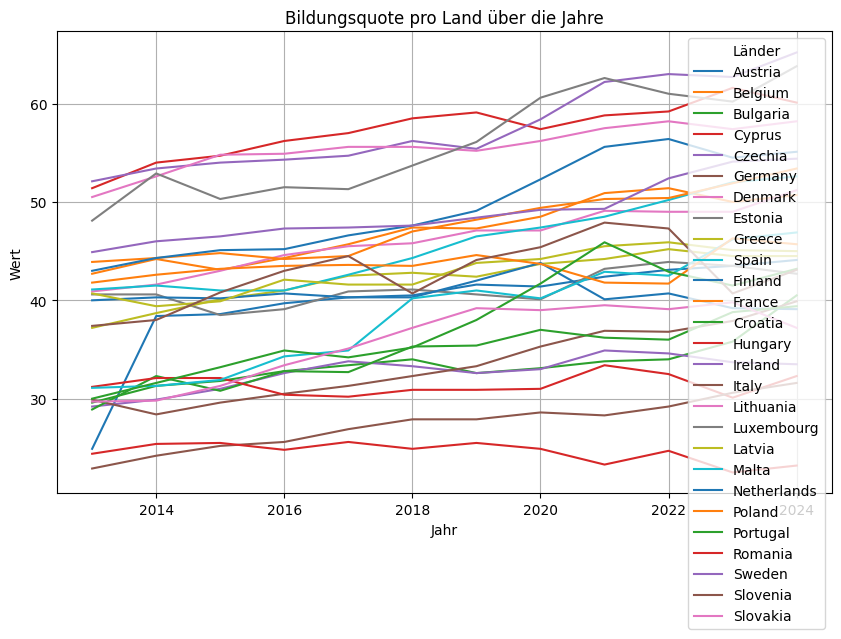

In [107]:
plt.figure(figsize=(10, 6))

# Durch jedes Land iterieren und eine Linie plotten
for country in df_ed['country'].unique():
    country_data = df_ed[df_ed['country'] == country]
    plt.plot(country_data['year'], country_data['education_rate'], label=country)

# Achsenbeschriftungen und Titel hinzufügen
plt.xlabel('Jahr')
plt.ylabel('Wert')
plt.title('Bildungsquote pro Land über die Jahre')
plt.legend(title='Länder')

# Plot anzeigen
plt.grid(True)
plt.show()

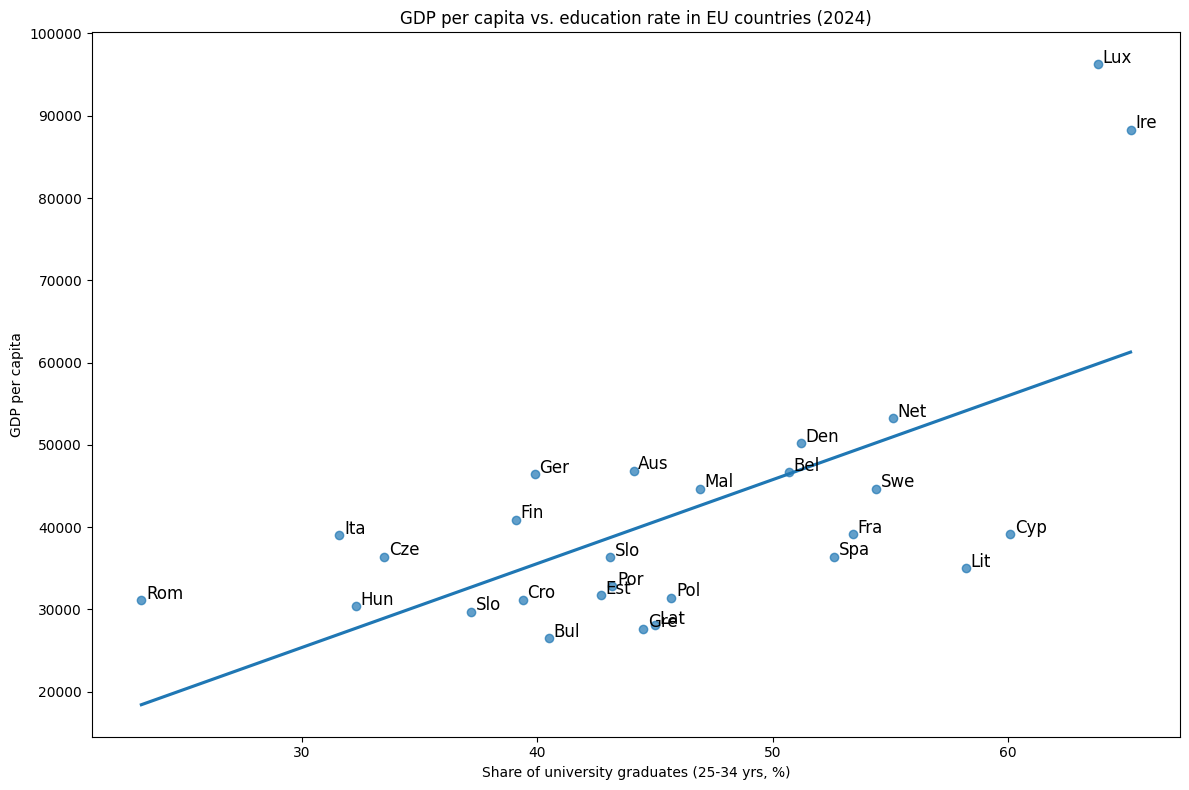

Pearson correlation (r): 0.63
Coefficient of determination (R2): 0.40


In [108]:
# Scatter plot: education rate vs. GDP per capita (using the latest available year)
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year]

# Calculate the Pearson correlation between education rate and GDP per capita
r = df_latest['education_rate'].corr(df_latest['gdp_per_capita'])

# Run a linear regression
X = df_latest[['education_rate']]
y = df_latest['gdp_per_capita']
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r_squared = model.score(X, y)

# Create scatter plot with regression line
plt.figure(figsize=(12, 8))
sns.regplot(data=df_latest, x='education_rate', y='gdp_per_capita',
            ci=None, scatter_kws={'alpha': 0.7})

# Label country abbreviations next to each point
for _, row in df_latest.iterrows():
    short = row['country'][:3]
    plt.text(row['education_rate'] + 0.2,
             row['gdp_per_capita'] + 200,
             short, fontsize=12)

plt.title(f'GDP per capita vs. education rate in EU countries ({df_latest["year"].iloc[0]})')
plt.xlabel('Share of university graduates (25-34 yrs, %)')
plt.ylabel('GDP per capita')
plt.tight_layout()
plt.show()

print(f"Pearson correlation (r): {r:.2f}")
print(f"Coefficient of determination (R2): {r_squared:.2f}")

### Luxemburg und Irland könnten Ausreisser sein. Im nächsten Schritt wird dies geprüft.

In [109]:
df['country'].describe()

count         270
unique         27
top       Austria
freq           10
Name: country, dtype: object

In [110]:
# Interquartile Range (IQR) Methode zur Ausreisser-Erkennung
# Diese Methode identifiziert Länder mit ungewöhnlich hohem BIP pro Kopf

# 1. Quartile berechnen
Q1 = df_latest['gdp_per_capita'].quantile(0.25)  # 25. Perzentil
Q3 = df_latest['gdp_per_capita'].quantile(0.75)  # 75. Perzentil
IQR = Q3 - Q1  # Interquartilsabstand

# 2. Schwellenwerte für Ausreisser definieren
# Standard-Regel: Werte ausserhalb von [Q1 - 1.5*IQR, Q3 + 1.5*IQR] sind Ausreisser
upper = Q3 + 1.5 * IQR  # Obergrenze


# 3. Länder mit extrem hohem BIP pro Kopf identifizieren
outliers_iqr = df_latest[df_latest['gdp_per_capita'] > upper]
print("Länder mit ungewöhnlich hohem BIP pro Kopf (Ausreisser):")
print(outliers_iqr[['country', 'gdp_per_capita']])

Länder mit ungewöhnlich hohem BIP pro Kopf (Ausreisser):
        country  gdp_per_capita
149     Ireland         88284.9
179  Luxembourg         96249.0


### Wird geprüft ob es bei der Ausbildung auch Länder mit ausreissern gibt.

In [111]:
# Interquartile Range (IQR) Methode zur Ausreisser-Erkennung in der Bildungsquote
# Diese Methode identifiziert Länder mit ungewöhnlich hoher oder niedriger Bildungsquote

# 1. Quartile berechnen
Q1 = df_latest['education_rate'].quantile(0.25)  # 25. Perzentil
Q3 = df_latest['education_rate'].quantile(0.75)  # 75. Perzentil
IQR = Q3 - Q1  # Interquartilsabstand

# 2. Schwellenwerte für Ausreisser definieren
lower = Q1 - 1.5 * IQR  # Untergrenze
upper = Q3 + 1.5 * IQR  # Obergrenze

# 3. Länder mit ungewöhnlicher Bildungsquote identifizieren
outliers_high = df_latest[df_latest['education_rate'] > upper]
outliers_low = df_latest[df_latest['education_rate'] < lower]

print("Länder mit ungewöhnlich HOHER Bildungsquote:")
print(outliers_high[['country', 'education_rate']])

print("\nLänder mit ungewöhnlich NIEDRIGER Bildungsquote:")
print(outliers_low[['country', 'education_rate']])

Länder mit ungewöhnlich HOHER Bildungsquote:
Empty DataFrame
Columns: [country, education_rate]
Index: []

Länder mit ungewöhnlich NIEDRIGER Bildungsquote:
Empty DataFrame
Columns: [country, education_rate]
Index: []


### Es gibt keine.

### Luxemburg und Irland sind Ausreisser und werden entfernt.

In [112]:
eu_ohn_aus = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia", "Finland", 
    "France", "Germany", "Greece", "Hungary", "Italy", "Latvia", "Lithuania", 
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia", "Spain", "Sweden"
]

In [113]:
#Filtern nach nur EU Ländern die Dataframes
df_ohn_aus = df[df['country'].isin(eu_ohn_aus)]
print(df_ohn_aus['country'].describe()) #Check ob alle drin sind 27 brauchen wir

count         250
unique         25
top       Austria
freq           10
Name: country, dtype: object


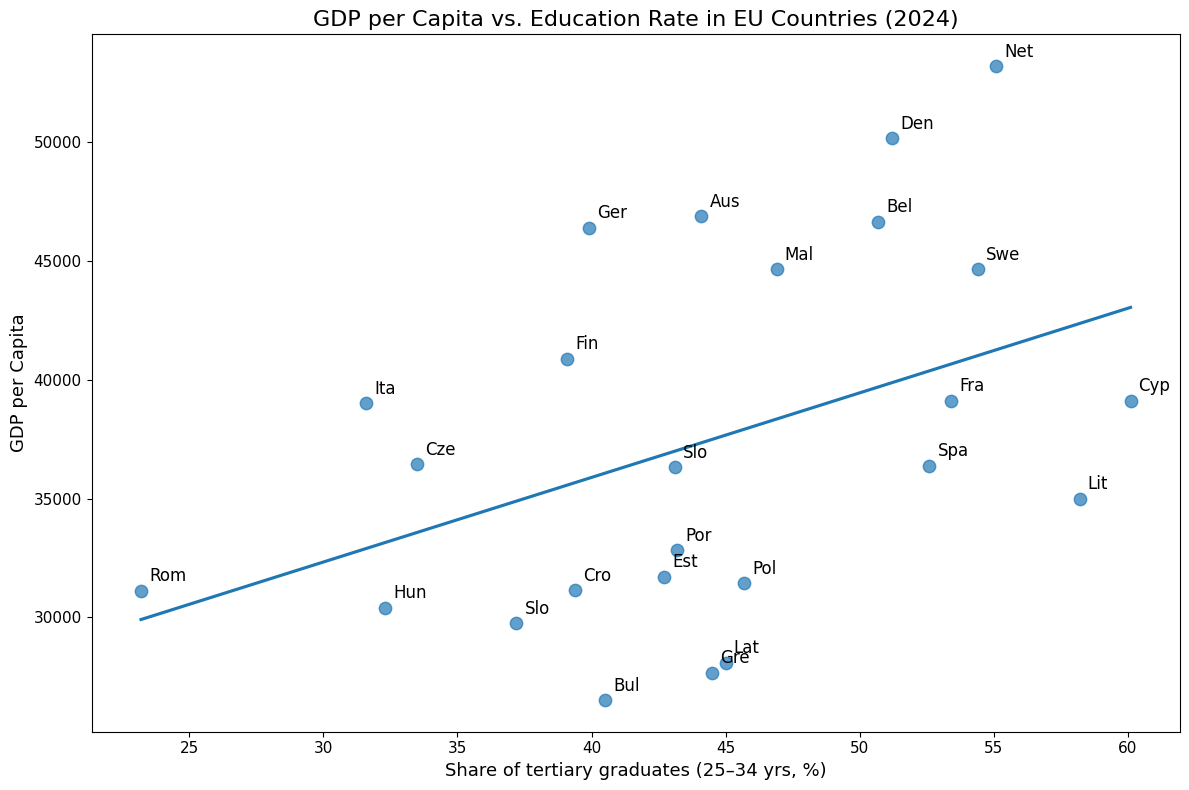

Pearson correlation (r): 0.42
Coefficient of determination (R²): 0.18


In [114]:
# Scatterplot: education rate vs GDP per capita (using e.g. data from the most recent available year)
latest_year = df_ohn_aus['year'].max()
df_ohn_aus_latest = df_ohn_aus[df_ohn_aus['year'] == latest_year]

# Calculate Pearson correlation between education rate and GDP per capita
r = df_ohn_aus_latest['education_rate'].corr(df_ohn_aus_latest['gdp_per_capita'])

# Perform linear regression
X = df_ohn_aus_latest[['education_rate']]  # Independent variable
y = df_ohn_aus_latest['gdp_per_capita']    # Dependent variable 
model = LinearRegression().fit(X, y)  # Train the model
y_pred = model.predict(X)  # Predict y coordinates given x
r_squared = model.score(X, y)  # Calculate the coefficient of determination (R²)

# Create scatterplot with regression line
plt.figure(figsize=(12, 8))
sns.regplot(data=df_ohn_aus_latest, x='education_rate', y='gdp_per_capita', 
            ci=None, scatter_kws={'alpha': 0.7, 's': 80}) #ci=None: show trend line only, no confidence interval

# Add country abbreviations (first 3 letters) next to each point
for _, row in df_ohn_aus_latest.iterrows():
    short = row['country'][:3]  # Extract first 3 letters of the country name
    plt.text(row['education_rate'] + 0.3, 
             row['gdp_per_capita'] + 400, 
             short, fontsize=12)

plt.title(f'GDP per Capita vs. Education Rate in EU Countries ({df_ohn_aus_latest["year"].iloc[0]})', fontsize=16)
plt.xlabel('Share of tertiary graduates (25–34 yrs, %)', fontsize=13)
plt.ylabel('GDP per Capita', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


# 9. Output the results
print(f"Pearson correlation (r): {r:.2f}")
print(f"Coefficient of determination (R²): {r_squared:.2f}")

In diesem Plot sieht man, dass die Punkte tendenziell ansteigend verlaufen: Länder mit einem höheren Anteil Hochschulabsolventen (x-Achse) weisen meistens ein höheres BIP pro Kopf (y-Achse) auf. Die Regressionsgerade (Trendlinie) steigt nach rechts oben, was auf einen positiven Zusammenhang hindeutet. 

2024 haben wohlhabendere EU-Länder tendenziell höhere Bildungsquoten, **aber das sagt uns nichts über kausale Zusammenhänge aus.** 
Der Pearson-Korrelationskoeffizient liegt bei r = 0.42.
Die lineare Regression erklärt 18 % der Variation im BIP pro Kopf (R² = 0.18), was auf weitere Einflussfaktoren neben der Bildung hinweist.

Das entfernen des Ausreissers hat einen Einfluss auf die Korrelation. Der Korrelationskoeffizient ist von 0.63 auf 0.42 gesunken. Dies zeigt, dass Luxemburg als Ausreisser den positiven Zusammenhang zwischen Bildungsquote und BIP pro Kopf verstärkt hat. In der weiteren Analyse werden nicht mehr Länder miteinander verglichen, sondern jedes Land einzeln analysiert. Ausreisser werden somit nicht mehr entfernt.

## Analyse der Hypothesen


### Hypothese 1: Bildungsquote vs. BIP pro Kopf
**These:** EU-Länder mit höherem Anteil an Hochschulabsolventen (Bildungsquote) weisen ein höheres BIP pro Kopf auf.

Wir untersuchen zunächst, ob ein positiver Zusammenhang zwischen der Bildungsquote und der wirtschaftlichen Leistung (BIP pro Kopf) besteht.

In [115]:
# Berechne für jedes Land die Korrelation zwischen Bildungsquote und BIP über Zeit
results_h1 = []

for country in df['country'].unique(): 
    country_data = df[df['country'] == country]
    
    # Pearson-Korrelation zwischen Bildungsquote und BIP pro Kopf
    correlation, p_value = pearsonr(country_data['education_rate'], country_data['gdp_per_capita'])
    
    # Ergebnisse speichern
    results_h1.append({
        'country': country,
        'correlation': correlation,
        'p_value': p_value
    })

# Ergebnisse als DataFrame
df_corr_h1 = pd.DataFrame(results_h1)

# Sortieren nach Korrelationsstärke
df_corr_h1_sorted = df_corr_h1.sort_values('correlation', ascending=False)

print(df_corr_h1_sorted)

        country  correlation       p_value
14      Ireland     0.980037  6.783330e-07
24       Sweden     0.971168  2.919879e-06
6       Denmark     0.949943  2.585233e-05
0       Austria     0.933772  7.766263e-05
19        Malta     0.933391  7.942708e-05
5       Germany     0.930662  9.295156e-05
16    Lithuania     0.928847  1.028447e-04
11       France     0.925841  1.209060e-04
15        Italy     0.910265  2.542595e-04
7       Estonia     0.908424  2.751487e-04
3        Cyprus     0.901381  3.668321e-04
12      Croatia     0.875451  9.034665e-04
20  Netherlands     0.855010  1.616963e-03
2      Bulgaria     0.843858  2.144220e-03
18       Latvia     0.841011  2.296607e-03
9         Spain     0.839270  2.393550e-03
1       Belgium     0.823512  3.410105e-03
17   Luxembourg     0.768564  9.390887e-03
8        Greece     0.700958  2.392955e-02
22     Portugal     0.632760  4.959171e-02
4       Czechia     0.562359  9.061432e-02
26     Slovakia     0.492723  1.479271e-01
21       Po

In [116]:
# Trenne signifikante (p < 0.05) und nicht-signifikante Länder
significant_h1 = df_corr_h1[df_corr_h1['p_value'] < 0.05].sort_values('correlation', ascending=False)
not_significant_h1 = df_corr_h1[df_corr_h1['p_value'] >= 0.05].sort_values('correlation', ascending=False)

print("\nSIGNIFIKANTE KORRELATIONEN (p < 0.05)")
print(significant_h1)


SIGNIFIKANTE KORRELATIONEN (p < 0.05)
        country  correlation       p_value
14      Ireland     0.980037  6.783330e-07
24       Sweden     0.971168  2.919879e-06
6       Denmark     0.949943  2.585233e-05
0       Austria     0.933772  7.766263e-05
19        Malta     0.933391  7.942708e-05
5       Germany     0.930662  9.295156e-05
16    Lithuania     0.928847  1.028447e-04
11       France     0.925841  1.209060e-04
15        Italy     0.910265  2.542595e-04
7       Estonia     0.908424  2.751487e-04
3        Cyprus     0.901381  3.668321e-04
12      Croatia     0.875451  9.034665e-04
20  Netherlands     0.855010  1.616963e-03
2      Bulgaria     0.843858  2.144220e-03
18       Latvia     0.841011  2.296607e-03
9         Spain     0.839270  2.393550e-03
1       Belgium     0.823512  3.410105e-03
17   Luxembourg     0.768564  9.390887e-03
8        Greece     0.700958  2.392955e-02
22     Portugal     0.632760  4.959171e-02
23      Romania    -0.799802  5.476242e-03


In [117]:
print("\nNICHT-SIGNIFIKANTE KORRELATIONEN (p >= 0.05)")
print(not_significant_h1)


NICHT-SIGNIFIKANTE KORRELATIONEN (p >= 0.05)
     country  correlation   p_value
4    Czechia     0.562359  0.090614
26  Slovakia     0.492723  0.147927
21    Poland     0.355533  0.313348
13   Hungary     0.292496  0.412153
25  Slovenia     0.118189  0.745043
10   Finland    -0.394207  0.259645


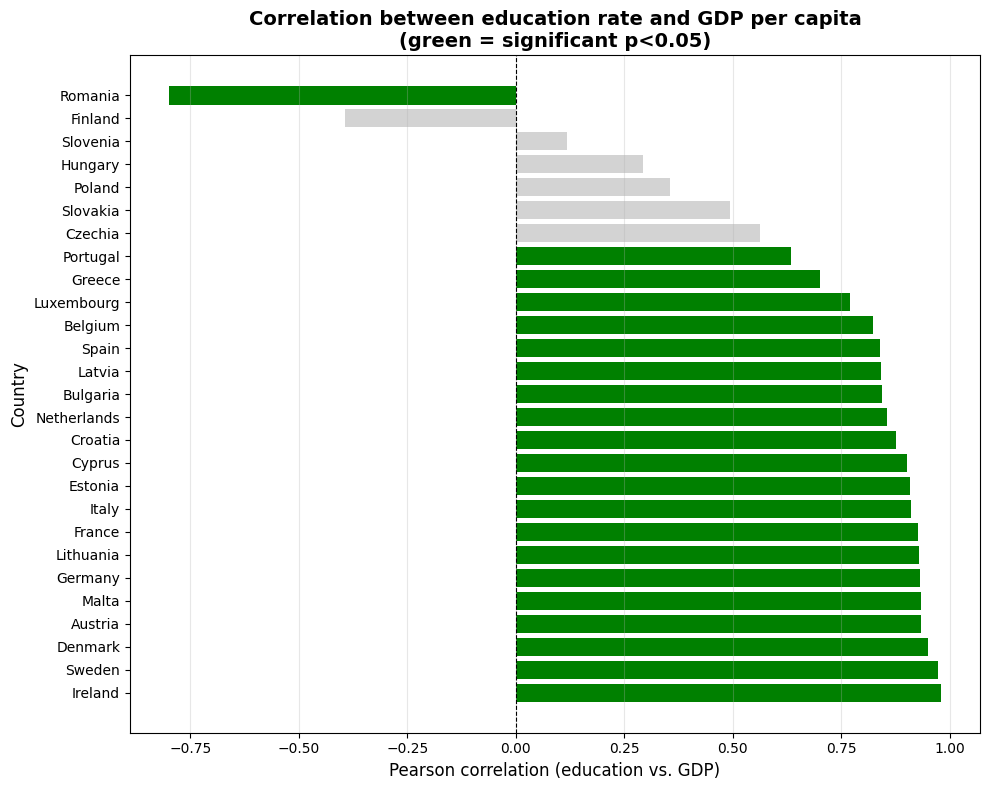

In [118]:
# Visualization: bar chart of correlations (sorted)
plt.figure(figsize=(10, 8))

# Color significant vs. non-significant differently
colors = ['green' if p < 0.05 
          else 'lightgray' for p in df_corr_h1_sorted['p_value']]

plt.barh(df_corr_h1_sorted['country'], df_corr_h1_sorted['correlation'], color=colors)
plt.xlabel('Pearson correlation (education vs. GDP)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Correlation between education rate and GDP per capita\n(green = significant p<0.05)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Beantwortung der Hypothese 1
### Ergebnis: In 21 von 27 EU-Ländern (78%) gibt es eine statistisch signifikante positive Korrelation zwischen der Bildungsquote und dem BIP pro Kopf (p < 0.05).
### 
### Interpretation:
### 
### Länder wie Irland (r=0.98), Schweden (r=0.97) und Dänemark (r=0.95) zeigen sehr starke positive Zusammenhänge
### 
### Bei den meisten EU-Ländern steigt das BIP pro Kopf, wenn der Anteil der Hochschulabsolventen steigt
### 
### Ausnahmen: Finnland zeigt sogar eine negative Korrelation (-0.39), allerdings nicht signifikant



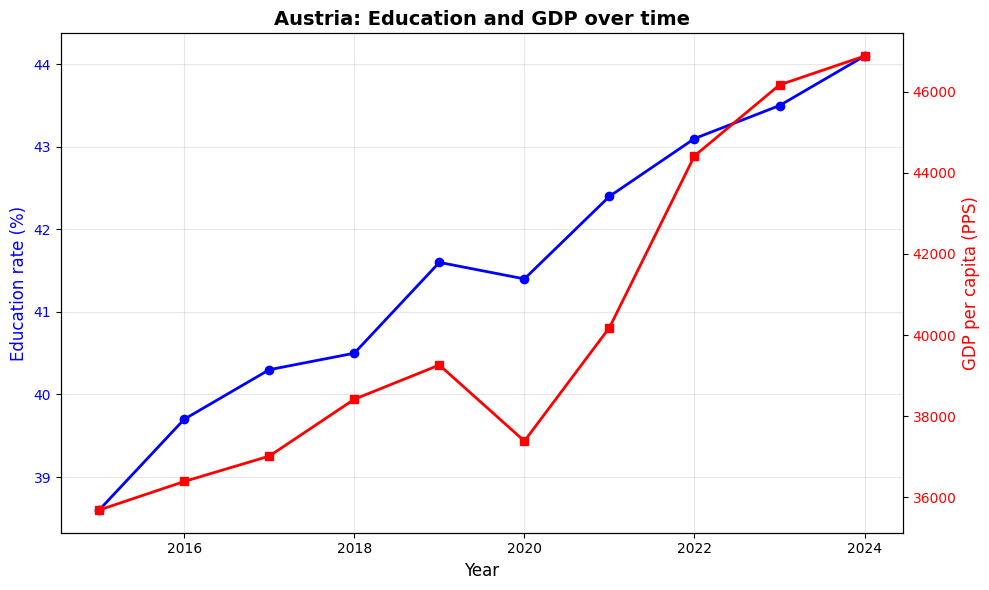

In [119]:
# Example 1: Country with a strong positive correlation
# Select the country with the strongest correlation
best_country = significant_h1.iloc[3]['country']
data_best = df[df['country'] == best_country]

# Create plot with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot education rate (blue line)
ax1.plot(data_best['year'], data_best['education_rate'], 
         color='blue', marker='o', linewidth=2, label='Education rate')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Education rate (%)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(alpha=0.3)

# Plot GDP (red line, other axis)
ax2 = ax1.twinx()
ax2.plot(data_best['year'], data_best['gdp_per_capita'], 
         color='red', marker='s', linewidth=2, label='GDP per capita')
ax2.set_ylabel('GDP per capita (PPS)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Title
plt.title(f'{best_country}: Education and GDP over time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Land ohne signifikanter Korrelation:

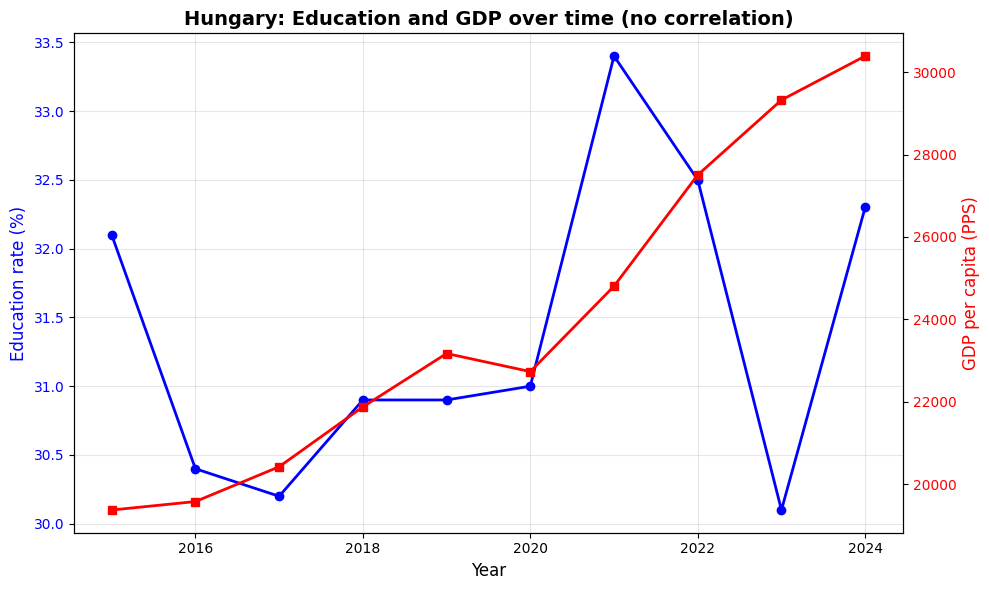

In [120]:
# Example: country without a significant correlation
weak_country = not_significant_h1.iloc[3]['country']
data_weak = df[df['country'] == weak_country]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Education rate
ax1.plot(data_weak['year'], data_weak['education_rate'], 
         color='blue', marker='o', linewidth=2)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Education rate (%)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(alpha=0.3)

# GDP
ax2 = ax1.twinx()
ax2.plot(data_weak['year'], data_weak['gdp_per_capita'], 
         color='red', marker='s', linewidth=2)
ax2.set_ylabel('GDP per capita (PPS)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'{weak_country}: Education and GDP over time (no correlation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Hypothese 2:
### Bildungsquote vs. Arbeitslosenquote

**Hypothese 2:** Haben Länder mit höherem Bildungsniveau eine niedrigere Arbeitslosenquote?

Wir untersuchen, ob ein Zusammenhang zwischen dem Anteil der Hochschulabsolventen und der Arbeitslosenquote in den EU-Ländern besteht.

Im Anschluss analysieren wir die Korrelation und interpretieren die Ergebnisse.

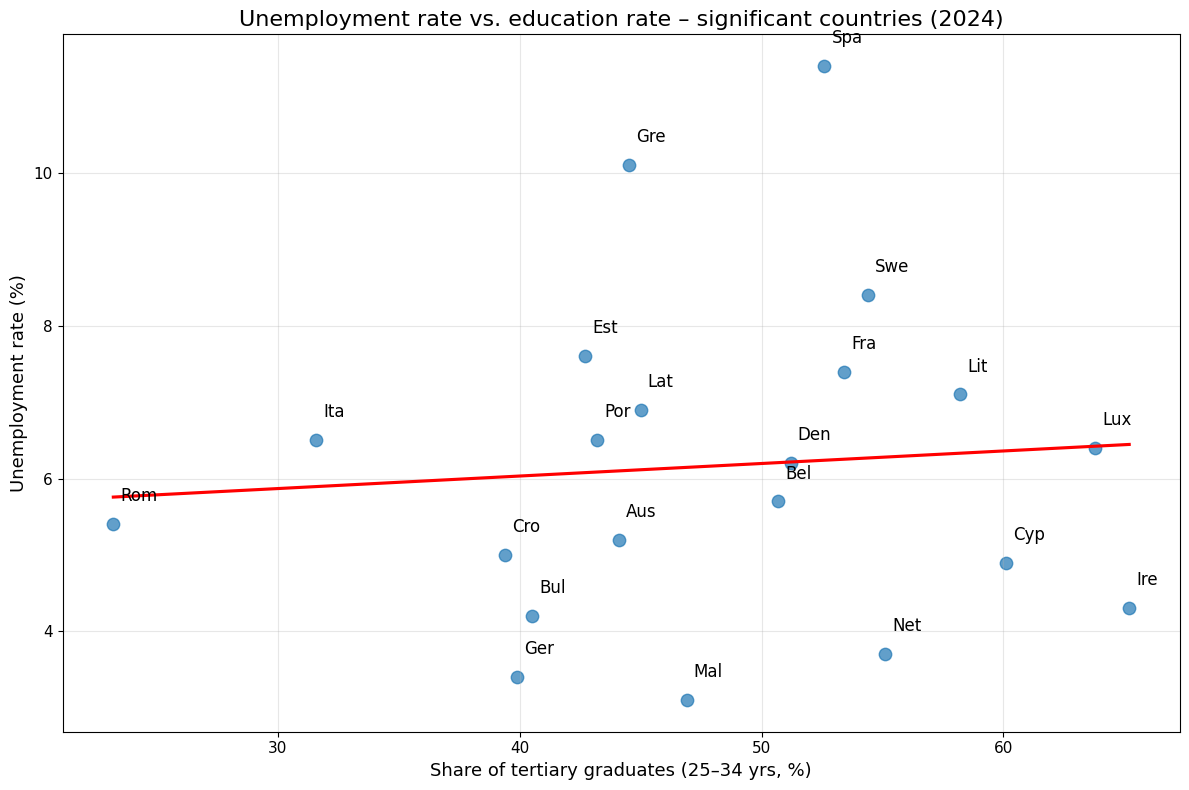

In [121]:
# Filter df to significant countries
significant_countries = significant_h1['country'].unique()
df_sig = df[df['country'].isin(significant_countries)]

# Use the latest available year
latest_year = df_sig['year'].max()
df_latest = df_sig[df_sig['year'] == latest_year]

# Scatter plot with regression line
plt.figure(figsize=(12, 8))
sns.regplot(
    data=df_latest,
    x='education_rate',
    y='unemployment_rate',
    ci=None,
    scatter_kws={'alpha': 0.7, 's': 80},
    line_kws={'color': 'red'}
)

# Label country abbreviations
for _, row in df_latest.iterrows():
    short = row['country'][:3]
    plt.text(
        row['education_rate'] + 0.3,
        row['unemployment_rate'] + 0.3,
        short,
        fontsize=12
    )

plt.title(f'Unemployment rate vs. education rate – significant countries ({latest_year})', fontsize=16)
plt.xlabel('Share of tertiary graduates (25–34 yrs, %)', fontsize=13)
plt.ylabel('Unemployment rate (%)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

### Ausreisser Check

In [122]:
# Interquartile Range (IQR) Methode zur Ausreisser-Erkennung in der Bildungsquote
# Diese Methode identifiziert Länder mit ungewöhnlich hoher oder niedriger Bildungsquote

# 1. Quartile berechnen
Q1 = df_latest['education_rate'].quantile(0.25)  # 25. Perzentil
Q3 = df_latest['education_rate'].quantile(0.75)  # 75. Perzentil
IQR = Q3 - Q1  # Interquartilsabstand

# 2. Schwellenwerte für Ausreisser definieren
lower = Q1 - 1.5 * IQR  # Untergrenze
upper = Q3 + 1.5 * IQR  # Obergrenze

# 3. Länder mit ungewöhnlicher Bildungsquote identifizieren
outliers_high = df_latest[df_latest['education_rate'] > upper]
outliers_low = df_latest[df_latest['education_rate'] < lower]

print("Länder mit ungewöhnlich HOHER Bildungsquote:")
print(outliers_high[['country', 'education_rate']])

print("\nLänder mit ungewöhnlich NIEDRIGER Bildungsquote:")
print(outliers_low[['country', 'education_rate']])


Länder mit ungewöhnlich HOHER Bildungsquote:
Empty DataFrame
Columns: [country, education_rate]
Index: []

Länder mit ungewöhnlich NIEDRIGER Bildungsquote:
     country  education_rate
239  Romania            23.2


In [123]:
# Interquartile Range (IQR) Methode zur Ausreißer-Erkennung in der Arbeitslosenquote
# Diese Methode identifiziert Länder mit ungewöhnlich hoher oder niedriger Arbeitslosenquote

# 1. Quartile berechnen
Q1 = df_latest['unemployment_rate'].quantile(0.25)  # 25. Perzentil
Q3 = df_latest['unemployment_rate'].quantile(0.75)  # 75. Perzentil
IQR = Q3 - Q1  # Interquartilsabstand

# 2. Schwellenwerte für Ausreißer definieren
lower = Q1 - 1.5 * IQR  # Untergrenze
upper = Q3 + 1.5 * IQR  # Obergrenze

# 3. Länder mit ungewöhnlicher Arbeitslosenquote identifizieren
outliers_high = df_latest[df_latest['unemployment_rate'] > upper]
outliers_low = df_latest[df_latest['unemployment_rate'] < lower]

print("Länder mit ungewöhnlich HOHER Arbeitslosenquote:")
print(outliers_high[['country', 'unemployment_rate']])

print("\nLänder mit ungewöhnlich NIEDRIGER Arbeitslosenquote:")
print(outliers_low[['country', 'unemployment_rate']])


Länder mit ungewöhnlich HOHER Arbeitslosenquote:
   country  unemployment_rate
99   Spain               11.4

Länder mit ungewöhnlich NIEDRIGER Arbeitslosenquote:
Empty DataFrame
Columns: [country, unemployment_rate]
Index: []


### Spanien ist bei der Arbeitslosenquote ein Ausreisser.

In [124]:
eu_ohn_span = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia", "Finland", 
    "France", "Germany", "Greece", "Hungary", "Italy", "Latvia", "Lithuania", 
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",  "Sweden"
]

In [125]:
df_latest = df_latest[df_latest['country'].isin(eu_ohn_span)]

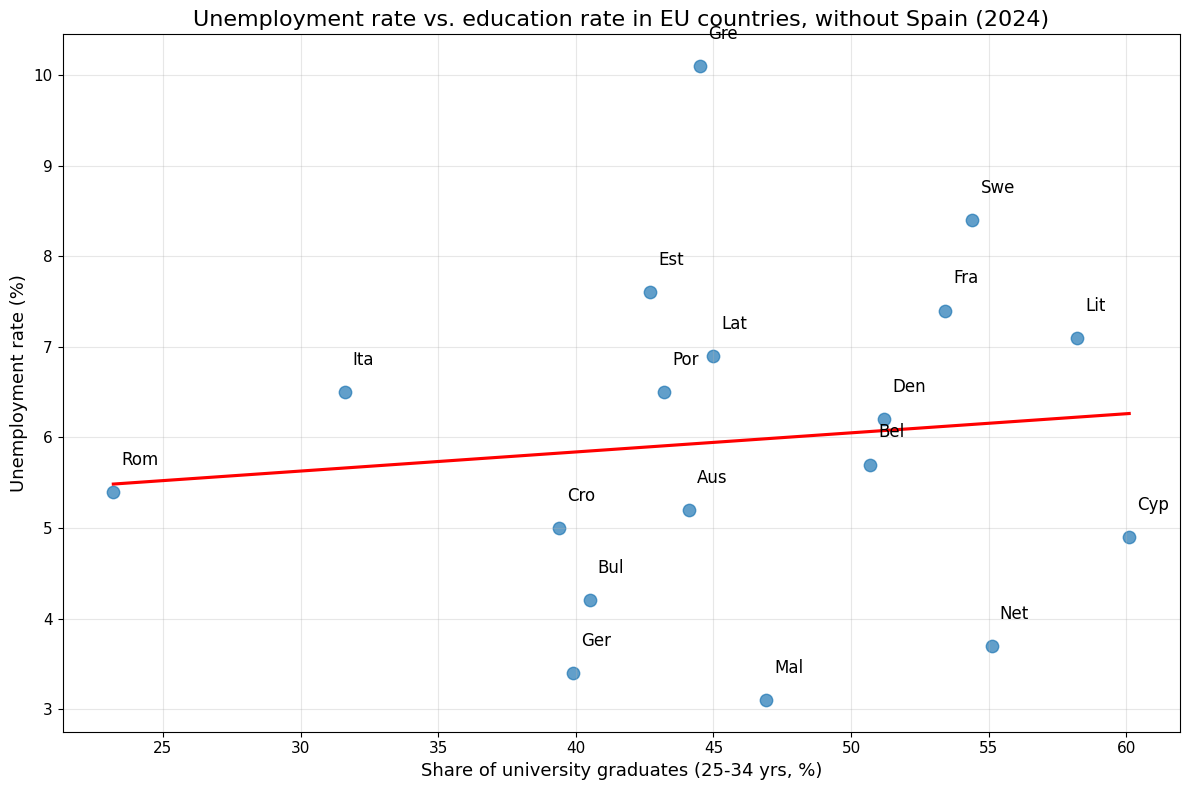

In [126]:
# Scatter plot with linear regression line, without Spain
plt.figure(figsize=(12, 8))
sns.regplot(data=df_latest, x='education_rate', y='unemployment_rate', ci=None, scatter_kws={'alpha': 0.7, 's': 80}, line_kws={'color': 'red'})

# Label country abbreviations
for _, row in df_latest.iterrows():
    short = row['country'][:3]
    plt.text(row['education_rate'] + 0.3,
             row['unemployment_rate'] + 0.3,
             short, fontsize=12)

plt.title(f'Unemployment rate vs. education rate in EU countries, without Spain ({latest_year})', fontsize=16)
plt.xlabel('Share of university graduates (25-34 yrs, %)', fontsize=13)
plt.ylabel('Unemployment rate (%)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [127]:
# Korrelationen für neuesten Jahrgang (aktuellste Daten, z.B. df_latest vom obigen Plot)

r_edu_unemp = df_latest['education_rate'].corr(df_latest['unemployment_rate'])
print(f"Pearson-Korrelation Bildung vs Arbeitslosenquote: {r_edu_unemp:.2f}")

Pearson-Korrelation Bildung vs Arbeitslosenquote: 0.11


<h4>Es scheint keine Korrelation zu geben: Die Punkte sind relativ verstreut, und die Regressionslinie ist nahezu horizontal. Mit einer Pearson-Korrelation von 0.4. Dies deutet darauf hin, dass die Bildungsquote keinen starken Einfluss auf die Arbeitslosenquote hat. Um tiefer in die Analyse zu steigen, Berechnen wir die Korrelationskoeffizienten für jedes Land einzeln über die Jahre</h4>

In [128]:
df

,country,year,education_rate,gdp_per_capita,unemployment_rate
0,Austria,2015,38.6,35681.6,6.1
1,Austria,2016,39.7,36385.4,6.5
2,Austria,2017,40.3,37011.9,5.9
3,Austria,2018,40.5,38414.6,5.2
4,Austria,2019,41.6,39259.3,4.8
...,...,...,...,...,...
265,Slovakia,2020,39.0,22559.3,6.7
266,Slovakia,2021,39.5,24477.8,6.8
267,Slovakia,2022,39.1,25618.8,6.1
268,Slovakia,2023,39.8,28282.8,5.8


In [129]:
# Leere Liste, um die Ergebnisse zu speichern
results = []
#Die Schleife for country in ... durchläuft jedes Land in dieser Liste der einzigartigen Länder und speichert es in der Variablen country
for country in df['country'].unique(): 
    country_data = df[df['country'] == country]  # Filtere das DataFrame für das Land
    correlation, p_value = pearsonr(country_data['education_rate'], country_data['unemployment_rate'])  # Berechne die Korrelation und den p-Wert # Berechne die Korrelation


        # Speichere die Ergebnisse in der Liste
    results.append({
        'country': country,
        'correlation': correlation,
        'p_value': p_value
    })


# Erstelle ein DataFrame mit den Ergebnissen
results_df = pd.DataFrame(results)

# Sortieren nach Korrelationsstärke
results_df = results_df.sort_values('correlation', ascending=False)

results_df


,country,correlation,p_value
24,Sweden,0.454177,0.187308
23,Romania,0.342317,0.332932
13,Hungary,0.132712,0.714751
7,Estonia,-0.023265,0.949135
21,Poland,-0.229694,0.523225
10,Finland,-0.232104,0.518752
17,Luxembourg,-0.243865,0.497153
25,Slovenia,-0.298596,0.402010
6,Denmark,-0.380835,0.277597
16,Lithuania,-0.420811,0.225895


In [130]:
significant_df = results_df[(results_df['p_value'] <= 0.05)]
significant_df = significant_df.sort_values(by='correlation',ascending=True)
# Ausgabe der gefilterten Daten

nsignificant_df = results_df[(results_df['p_value'] > 0.05)]
nsignificant_df = nsignificant_df.loc[
    nsignificant_df['correlation'].abs().sort_values().index
]


In [131]:
print(significant_df)
print(significant_df.count())

        country  correlation   p_value
15        Italy    -0.976653  0.000001
11       France    -0.945687  0.000036
8        Greece    -0.930125  0.000096
12      Croatia    -0.927314  0.000112
9         Spain    -0.922108  0.000146
3        Cyprus    -0.918557  0.000174
26     Slovakia    -0.907364  0.000288
20  Netherlands    -0.877430  0.000849
1       Belgium    -0.843557  0.002160
19        Malta    -0.822923  0.003453
22     Portugal    -0.753969  0.011765
18       Latvia    -0.743776  0.013655
14      Ireland    -0.727487  0.017099
4       Czechia    -0.671122  0.033621
country        14
correlation    14
p_value        14
dtype: int64


### Bei 14 Länder besteht ein statistisch signifikanter, mittelstarker bis starker Zusammenhang zwischen Bildungsquote und Arbeitslosenquote.

In [132]:
print(nsignificant_df)
print(nsignificant_df.count())

       country  correlation   p_value
7      Estonia    -0.023265  0.949135
13     Hungary     0.132712  0.714751
21      Poland    -0.229694  0.523225
10     Finland    -0.232104  0.518752
17  Luxembourg    -0.243865  0.497153
25    Slovenia    -0.298596  0.402010
23     Romania     0.342317  0.332932
6      Denmark    -0.380835  0.277597
16   Lithuania    -0.420811  0.225895
24      Sweden     0.454177  0.187308
5      Germany    -0.517715  0.125342
0      Austria    -0.594752  0.069742
2     Bulgaria    -0.605202  0.063748
country        13
correlation    13
p_value        13
dtype: int64


### Bei 13 Länder ist entweder keinen klare korrelation oder kein statistisch signifikantes Ergebnis zu beobachten.

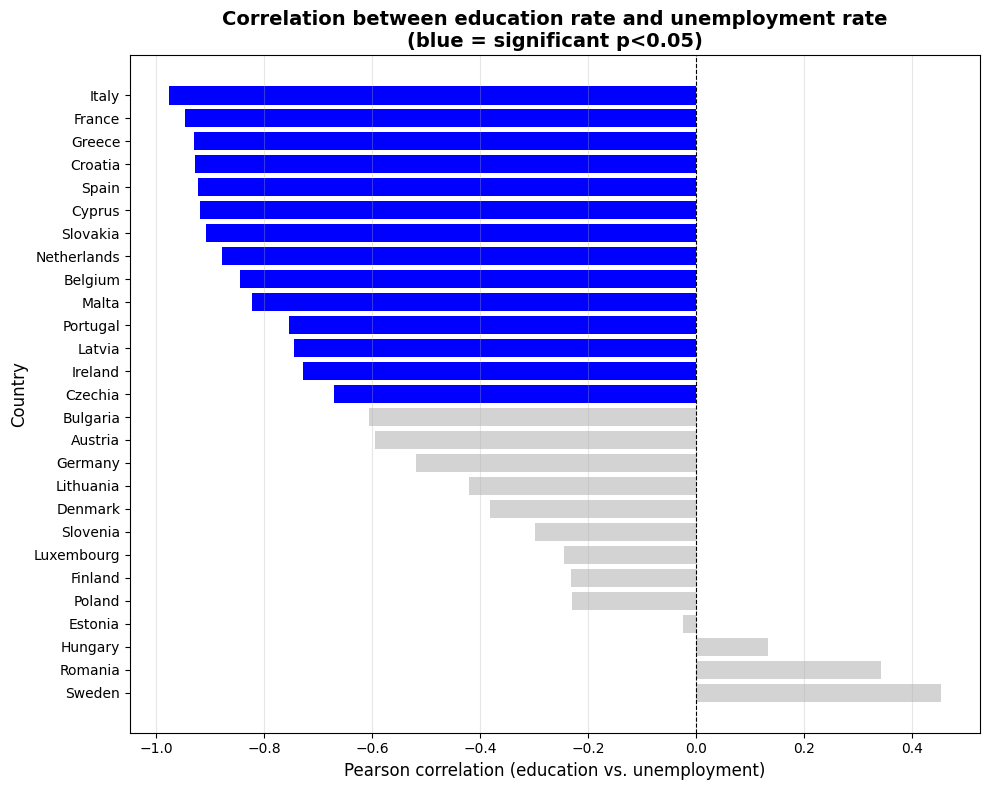

In [133]:
# Visualization: bar chart of correlations (sorted)
plt.figure(figsize=(10, 8))

# Color significant vs. non-significant differently
colors = ['blue' if p < 0.05 else 'lightgray' for p in results_df['p_value']]

plt.barh(results_df['country'], results_df['correlation'], color=colors)
plt.xlabel('Pearson correlation (education vs. unemployment)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Correlation between education rate and unemployment rate\n(blue = significant p<0.05)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Hypothese 2: Bildungsquote vs. Arbeitslosenquote
### In 14 von 27 EU-Ländern (52%) gibt es eine statistisch signifikante Korrelation zwischen Bildungsquote und Arbeitslosenquote (p < 0.05). Allerdings ist dieser Zusammenhang weniger konsistent als bei Hypothese 1 (78%). Die Hypothese wird eingeschränkt bestätigt der Zusammenhang existiert, ist aber schwächer und weniger einheitlich als bei den anderen Hypothesen.

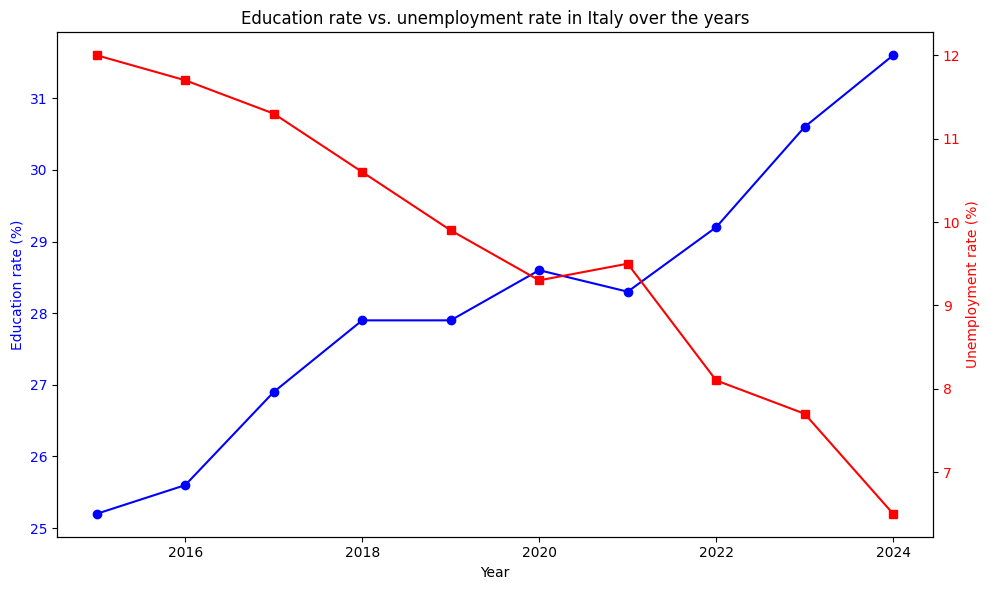

Italy – correlation (r): -0.98, p-value: 0.000001


In [134]:
# Filter the data for Italy
data = df[df['country'] == 'Italy']

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# First y-axis: education rate
ax1.set_xlabel('Year')
ax1.set_ylabel('Education rate (%)', color='blue')
ax1.plot(data['year'], data['education_rate'], color='blue', marker='o', label='Education rate')
ax1.tick_params(axis='y', labelcolor='blue')

# Second y-axis: unemployment rate
ax2 = ax1.twinx()
ax2.set_ylabel('Unemployment rate (%)', color='red')
ax2.plot(data['year'], data['unemployment_rate'], color='red', marker='s', label='Unemployment rate')
ax2.tick_params(axis='y', labelcolor='red')


# Title and layout
plt.title('Education rate vs. unemployment rate in Italy over the years')
fig.tight_layout()
plt.show()
italy_row = significant_df[significant_df['country'] == 'Italy']
r = italy_row['correlation'].values[0]
p = italy_row['p_value'].values[0]
print(f"Italy – correlation (r): {r:.2f}, p-value: {p:.6f}")

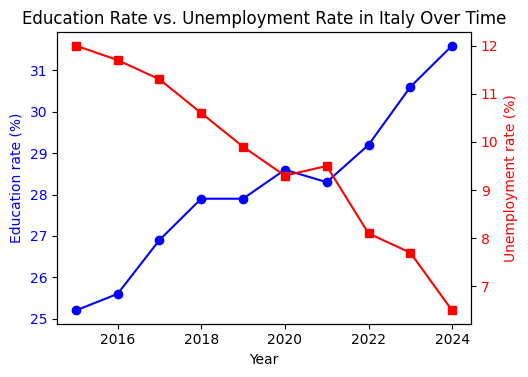

Italy – Correlation (r): -0.98, p-value: 0.000001


In [135]:
import matplotlib.pyplot as plt

# Filter the data for Italy
data = df[df['country'] == 'Italy']

# Create the plot (538 x 387 px)
fig, ax1 = plt.subplots(figsize=(5.38, 3.87), dpi=100)

# First Y-axis: Education rate
ax1.set_xlabel('Year')
ax1.set_ylabel('Education rate (%)', color='blue')
ax1.plot(
    data['year'],
    data['education_rate'],
    color='blue',
    marker='o',
    label='Education rate'
)
ax1.tick_params(axis='y', labelcolor='blue')

# Second Y-axis: Unemployment rate
ax2 = ax1.twinx()
ax2.set_ylabel('Unemployment rate (%)', color='red')
ax2.plot(
    data['year'],
    data['unemployment_rate'],
    color='red',
    marker='s',
    label='Unemployment rate'
)
ax2.tick_params(axis='y', labelcolor='red')

# Title and layout
plt.title('Education Rate vs. Unemployment Rate in Italy Over Time')
fig.tight_layout()

# Save exactly as 538 x 387 px
plt.savefig("italy_plot.png", dpi=100)

plt.show()

# Print correlation results
italy_row = significant_df[significant_df['country'] == 'Italy']
r = italy_row['correlation'].values[0]
p = italy_row['p_value'].values[0]

print(f"Italy – Correlation (r): {r:.2f}, p-value: {p:.6f}")

### Italien weist die stärkeste negative Korrelation auf (r = -0.98, p = 0.000001), was darauf hindeutet, dass in Italien ein höherer Anteil an Hochschulabsolventen mit einer niedrigeren Arbeitslosenquote verbunden ist.

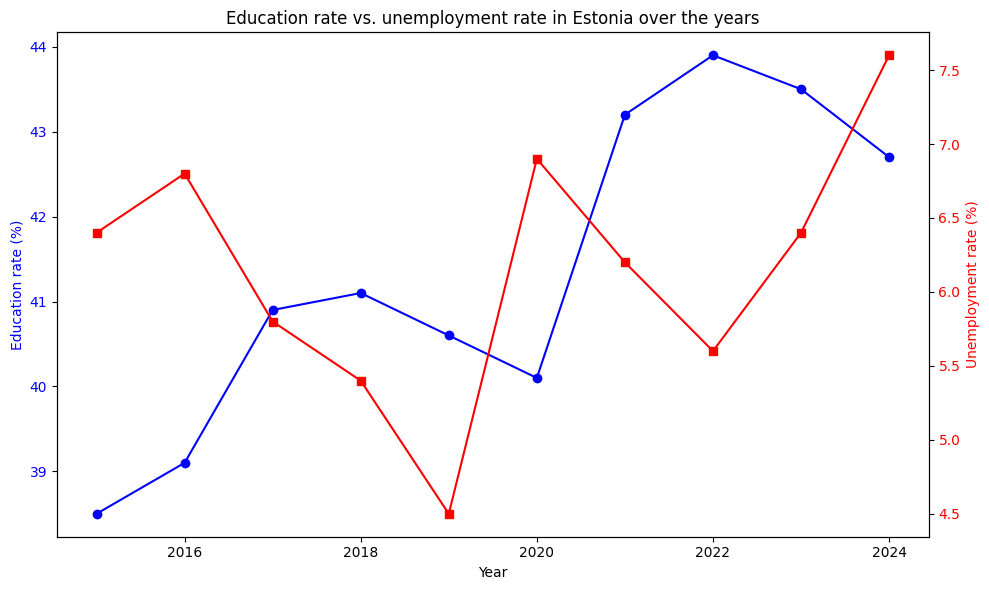

Estonia – correlation (r): -0.02, p-value: 0.949135


In [136]:
# Filter the data for Estonia
data = df[df['country'] == 'Estonia']

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# First y-axis: education rate
ax1.set_xlabel('Year')
ax1.set_ylabel('Education rate (%)', color='blue')
ax1.plot(data['year'], data['education_rate'], color='blue', marker='o', label='Education rate')
ax1.tick_params(axis='y', labelcolor='blue')

# Second y-axis: unemployment rate
ax2 = ax1.twinx()
ax2.set_ylabel('Unemployment rate (%)', color='red')
ax2.plot(data['year'], data['unemployment_rate'], color='red', marker='s', label='Unemployment rate')
ax2.tick_params(axis='y', labelcolor='red')

# Title and layout
plt.title('Education rate vs. unemployment rate in Estonia over the years')
fig.tight_layout()
plt.show()
estonia_row = nsignificant_df[nsignificant_df['country'] == 'Estonia']
r = estonia_row['correlation'].values[0]
p = estonia_row['p_value'].values[0]
print(f"Estonia – correlation (r): {r:.2f}, p-value: {p:.6f}")

### In Estland besteht kein erkennbarer Zusammenhang zwischen Bildungsquote und Arbeitslosenquote (r = –0.02, p = 0.95).

## Hypothese 3:
### BIP pro Kopf vs. Arbeitslosenquote


**Hypothese 3:** Haben Länder mit höherem BIP pro Kopf eine niedrigere Arbeitslosenquote?


Wir untersuchen, ob ein Zusammenhang zwischen dem Bruttoinlandsprodukt pro Kopf und der Arbeitslosenquote in den EU-Ländern besteht.


In [137]:
# ============================================================
# HYPOTHESE 3: BIP pro Kopf vs. Arbeitslosenquote (Within-Country)
# ============================================================

# Berechne für jedes Land die Korrelation zwischen BIP und Arbeitslosigkeit über Zeit
results_h3 = []

for country in df['country'].unique(): 
    country_data = df[df['country'] == country]
    
    # Pearson-Korrelation zwischen BIP pro Kopf und Arbeitslosenquote
    correlation, p_value = pearsonr(country_data['gdp_per_capita'], country_data['unemployment_rate'])
    
    # Ergebnisse speichern
    results_h3.append({
        'country': country,
        'correlation': correlation,
        'p_value': p_value
    })

# Ergebnisse als DataFrame
df_corr_h3 = pd.DataFrame(results_h3)

# Sortieren nach Korrelationsstärke
df_corr_h3_sorted = df_corr_h3.sort_values('correlation', ascending=False)

print(df_corr_h3_sorted)


        country  correlation   p_value
24       Sweden     0.532556  0.113009
7       Estonia     0.148055  0.683136
13      Hungary    -0.371537  0.290467
17   Luxembourg    -0.378764  0.280437
6       Denmark    -0.380718  0.277758
16    Lithuania    -0.484718  0.155649
10      Finland    -0.526478  0.117963
26     Slovakia    -0.600009  0.066683
5       Germany    -0.601055  0.066085
22     Portugal    -0.632833  0.049557
4       Czechia    -0.633705  0.049148
23      Romania    -0.645236  0.043938
0       Austria    -0.657322  0.038889
1       Belgium    -0.677958  0.031200
18       Latvia    -0.772185  0.008859
12      Croatia    -0.781498  0.007588
14      Ireland    -0.783730  0.007304
21       Poland    -0.797047  0.005763
9         Spain    -0.805112  0.004952
20  Netherlands    -0.820480  0.003636
25     Slovenia    -0.849981  0.001841
2      Bulgaria    -0.855321  0.001604
11       France    -0.861794  0.001346
3        Cyprus    -0.864552  0.001246
8        Greece    -0.879

In [138]:
# Trenne signifikante (p < 0.05) und nicht-signifikante Länder
significant_h3 = df_corr_h3[df_corr_h3['p_value'] < 0.05].sort_values('correlation', ascending=False)
not_significant_h3 = df_corr_h3[df_corr_h3['p_value'] >= 0.05].sort_values('correlation', ascending=False)

print("\nSIGNIFIKANTE KORRELATIONEN (p < 0.05)")
print(significant_h3)
print(f"\nAnzahl Länder mit signifikanter Korrelation: {len(significant_h3)}")




SIGNIFIKANTE KORRELATIONEN (p < 0.05)
        country  correlation   p_value
22     Portugal    -0.632833  0.049557
4       Czechia    -0.633705  0.049148
23      Romania    -0.645236  0.043938
0       Austria    -0.657322  0.038889
1       Belgium    -0.677958  0.031200
18       Latvia    -0.772185  0.008859
12      Croatia    -0.781498  0.007588
14      Ireland    -0.783730  0.007304
21       Poland    -0.797047  0.005763
9         Spain    -0.805112  0.004952
20  Netherlands    -0.820480  0.003636
25     Slovenia    -0.849981  0.001841
2      Bulgaria    -0.855321  0.001604
11       France    -0.861794  0.001346
3        Cyprus    -0.864552  0.001246
8        Greece    -0.879355  0.000799
19        Malta    -0.881841  0.000738
15        Italy    -0.929077  0.000102

Anzahl Länder mit signifikanter Korrelation: 18


In [139]:
print("\nNICHT-SIGNIFIKANTE KORRELATIONEN (p >= 0.05)")
print(not_significant_h3)
print(f"\nAnzahl Länder ohne signifikante Korrelation: {len(not_significant_h3)}")


NICHT-SIGNIFIKANTE KORRELATIONEN (p >= 0.05)
       country  correlation   p_value
24      Sweden     0.532556  0.113009
7      Estonia     0.148055  0.683136
13     Hungary    -0.371537  0.290467
17  Luxembourg    -0.378764  0.280437
6      Denmark    -0.380718  0.277758
16   Lithuania    -0.484718  0.155649
10     Finland    -0.526478  0.117963
26    Slovakia    -0.600009  0.066683
5      Germany    -0.601055  0.066085

Anzahl Länder ohne signifikante Korrelation: 9


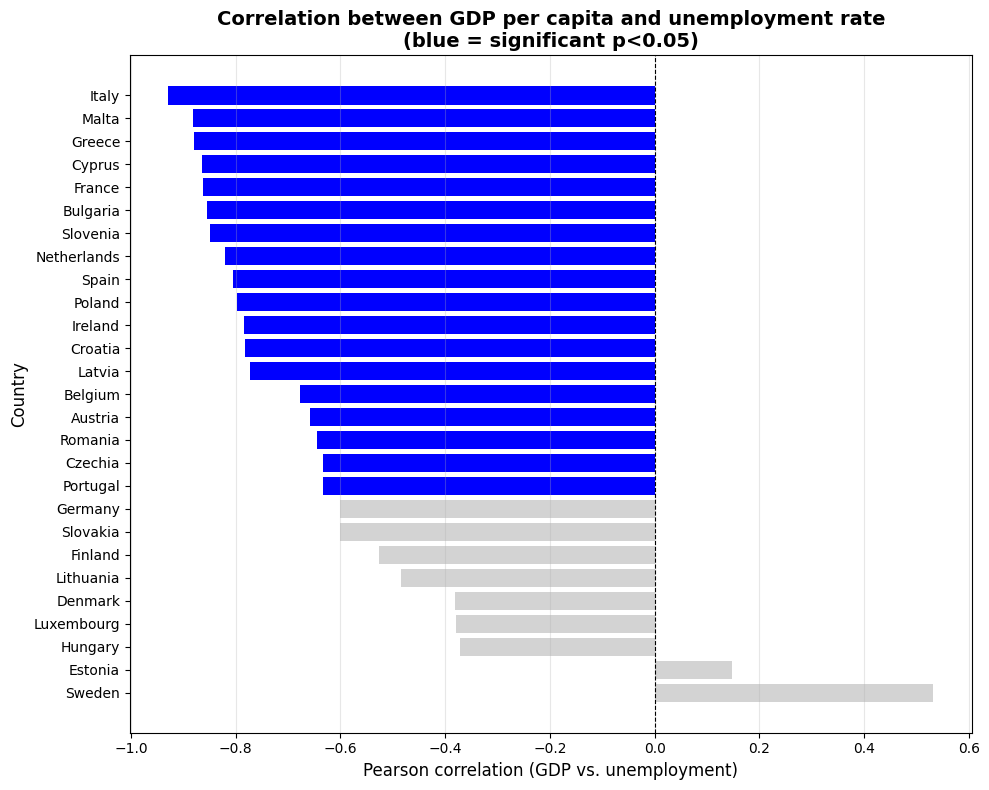

In [140]:
# Visualization: bar chart of correlations (sorted)
plt.figure(figsize=(10, 8))

# Color significant vs. non-significant differently
colors = ['blue' if p < 0.05 else 'lightgray' for p in df_corr_h3_sorted['p_value']]

plt.barh(df_corr_h3_sorted['country'], df_corr_h3_sorted['correlation'], color=colors)
plt.xlabel('Pearson correlation (GDP vs. unemployment)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Correlation between GDP per capita and unemployment rate\n(blue = significant p<0.05)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Hypothese 3: BIP vs. Arbeitslosenquote
Die Hypothese wird für die 66.6% der untersuchten Länder (18 von 27) bestätigt.
In diesen Ländern gibt es einen signifikanten negativen Zusammenhang: Das bedeutet, wenn das BIP pro Kopf steigt, sinkt die Arbeitslosenquote.

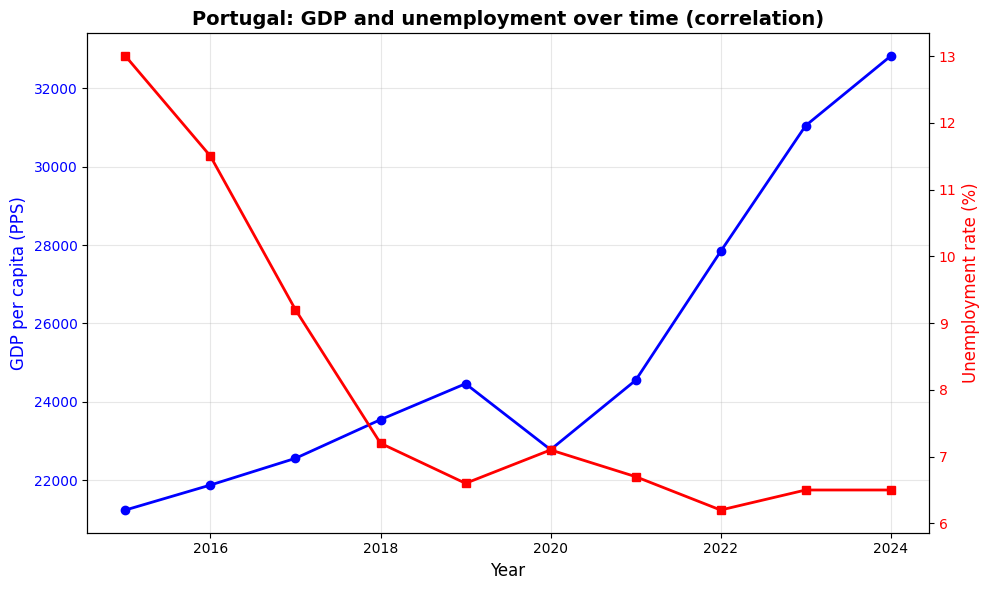

In [141]:
# Example 1: Country with a strong negative correlation (high GDP → low unemployment)
best_country = significant_h3.iloc[0]['country']
data_best = df[df['country'] == best_country]

# Create plot with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot GDP (blue line)
ax1.plot(data_best['year'], data_best['gdp_per_capita'], 
         color='blue', marker='o', linewidth=2)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('GDP per capita (PPS)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(alpha=0.3)

# Plot unemployment (red line, other axis)
ax2 = ax1.twinx()
ax2.plot(data_best['year'], data_best['unemployment_rate'], 
         color='red', marker='s', linewidth=2)
ax2.set_ylabel('Unemployment rate (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Title
plt.title(f'{best_country}: GDP and unemployment over time (correlation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

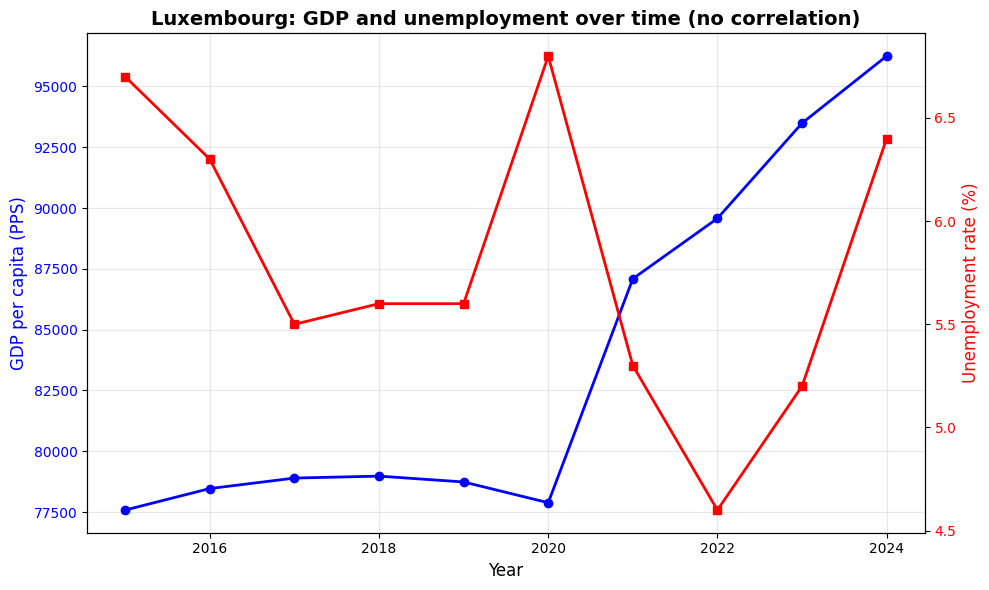

In [142]:
# Example 2: Country without a significant correlation
weak_country = not_significant_h3.iloc[3]['country']
data_weak = df[df['country'] == weak_country]

fig, ax1 = plt.subplots(figsize=(10, 6))

# GDP
ax1.plot(data_weak['year'], data_weak['gdp_per_capita'], 
         color='blue', marker='o', linewidth=2)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('GDP per capita (PPS)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(alpha=0.3)

# Unemployment
ax2 = ax1.twinx()
ax2.plot(data_weak['year'], data_weak['unemployment_rate'], 
         color='red', marker='s', linewidth=2)
ax2.set_ylabel('Unemployment rate (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'{weak_country}: GDP and unemployment over time (no correlation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Kritische Würdigung und Limitationen


### Korrelation vs. Kausalität:
Die nachgewiesenen Korrelationen belegen keine Kausalität. Ein steigendes BIP und eine steigende Bildungsquote können auch das Ergebnis eines gemeinsamen dritten Faktors sein (z.B. allgemeiner technologischer Fortschritt über die Zeit), ohne dass das eine das andere direkt verursacht.

### Zeitliche Trends:
Die Analyse betrachtete Korrelationen innerhalb einzelner Länder über die Zeit. Vergleich der Länder-Mittelwerte untereinander wäre wahrscheinlich robuster gewesen, um zu prüfen, ob "klügere" Länder auch "reichere" Länder sind.

<h1>Vergleich Tertiäre Ausbildung Schweiz vs. Nachbarn</h1>

In [143]:
relevant_countries = [
    "Austria", "France", "Germany", "Italy", "Switzerland", "European Union - 27 countries (from 2020)"
]



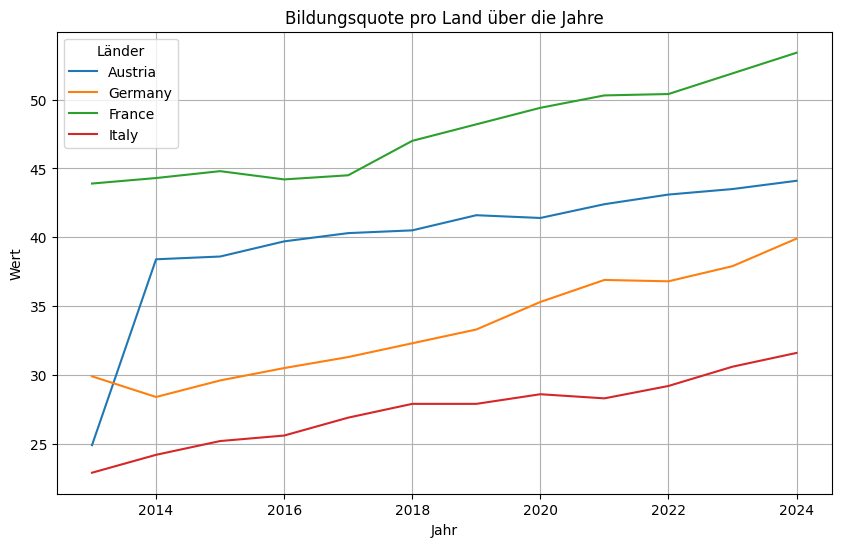

In [144]:
df_nei = df_ed[df_ed['country'].isin(relevant_countries)]

plt.figure(figsize=(10, 6))

# Durch jedes Land iterieren und eine Linie plotten
for country in df_nei['country'].unique():
    country_data = df_nei[df_nei['country'] == country]
    plt.plot(country_data['year'], country_data['education_rate'], label=country)

# Achsenbeschriftungen und Titel hinzufügen
plt.xlabel('Jahr')
plt.ylabel('Wert')
plt.title('Bildungsquote pro Land über die Jahre')
plt.legend(title='Länder')

# Plot anzeigen
plt.grid(True)
plt.show()